Dataset shape: (200, 5)
Columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:
    Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


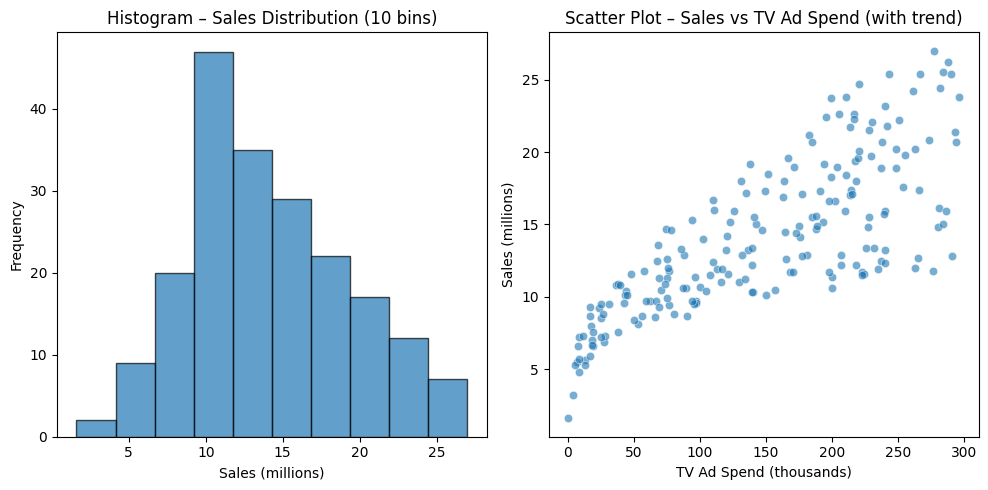

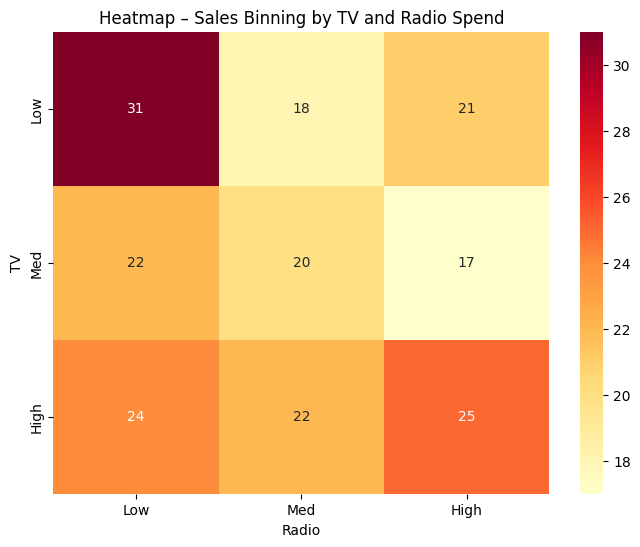

Simple Linear Regression (Sales ~ TV):
Slope (coef): 0.05
Intercept: 7.12
R² Score: 0.677

Multiple Linear Regression (Sales ~ TV + Radio + Newspaper):
Coefficients: {'TV': np.float64(0.04), 'Radio': np.float64(0.19), 'Newspaper': np.float64(0.0)}
Intercept: 2.98
R² Score: 0.899


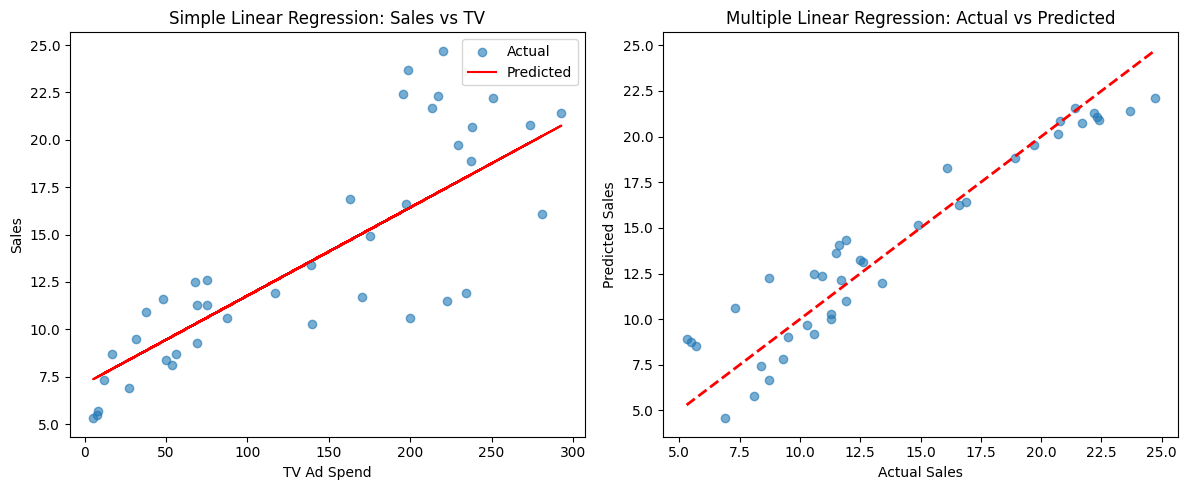

In [2]:
# Assignment 3: Binning Visualizations + Linear Regression
# Dataset: Advertising dataset from Kaggle (advertising.csv) [web:96]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load dataset
df = pd.read_csv("Advertising.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

# ---------- PART 1: BINNING VISUALIZATIONS ----------

# Binning visualization 1: Histogram of Sales with 10 bins
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Sales'], bins=10, edgecolor='black', alpha=0.7)
plt.title("Histogram – Sales Distribution (10 bins)")
plt.xlabel("Sales (millions)")
plt.ylabel("Frequency")

# Binning visualization 2: Scatter plot Sales vs TV
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TV', y='Sales', alpha=0.6)
plt.title("Scatter Plot – Sales vs TV Ad Spend (with trend)")
plt.xlabel("TV Ad Spend (thousands)")
plt.ylabel("Sales (millions)")
plt.tight_layout()
plt.show()

# Binning visualization 3: Heatmap of Sales binned by TV and Radio
plt.figure(figsize=(8, 6))
sales_bins = pd.cut(df['Sales'], bins=5, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])
tv_radio_bins = pd.cut(df['TV'], bins=3, labels=['Low', 'Med', 'High'])
heatmap_data = pd.crosstab(tv_radio_bins, pd.cut(df['Radio'], bins=3, labels=['Low', 'Med', 'High']), values=sales_bins, aggfunc='count')
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd')
plt.title("Heatmap – Sales Binning by TV and Radio Spend")
plt.show()

# ---------- PART 2: LINEAR REGRESSION ----------

# Simple Linear Regression: Sales ~ TV
X_simple = df[['TV']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

print("Simple Linear Regression (Sales ~ TV):")
print(f"Slope (coef): {model_simple.coef_[0]:.2f}")
print(f"Intercept: {model_simple.intercept_:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_simple):.3f}")

# Multiple Linear Regression: Sales ~ TV + Radio + Newspaper
X_multiple = df[['TV', 'Radio', 'Newspaper']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y, test_size=0.2, random_state=42)

model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)
y_pred_multiple = model_multiple.predict(X_test_m)

print("\nMultiple Linear Regression (Sales ~ TV + Radio + Newspaper):")
print("Coefficients:", dict(zip(X_multiple.columns, model_multiple.coef_.round(2))))
print(f"Intercept: {model_multiple.intercept_:.2f}")
print(f"R² Score: {r2_score(y_test_m, y_pred_multiple):.3f}")

# Visualization of regression results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, alpha=0.6, label='Actual')
plt.plot(X_test, y_pred_simple, color='red', label='Predicted')
plt.title("Simple Linear Regression: Sales vs TV")
plt.xlabel("TV Ad Spend")
plt.ylabel("Sales")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_m, y_pred_multiple, alpha=0.6)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()
